In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
cd "/content/drive/MyDrive/Final Project/"

/content/drive/MyDrive/Final Project


In [14]:
ls

247_final/  output.txt  parser.ipynb


lines: 841
max epoch seen (any line): 110
max epoch in train_loss df: 78
max epoch in val_CER df: 68
   epoch  train_loss     val_CER
0      0      122.00  1358.21887
1      1        3.43   100.00000
2      2        3.25   100.00000
3      3        3.21   100.00000
4      4        3.19   100.00000


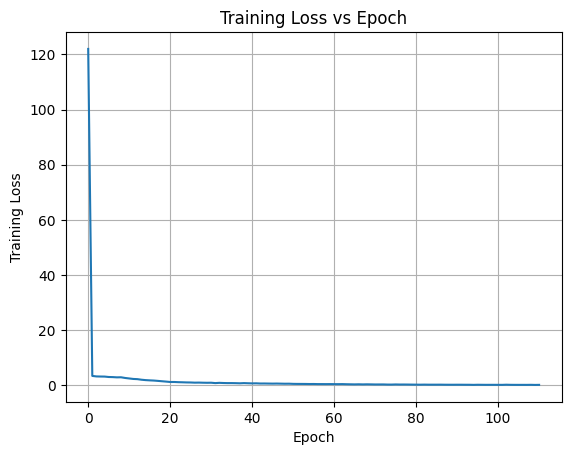

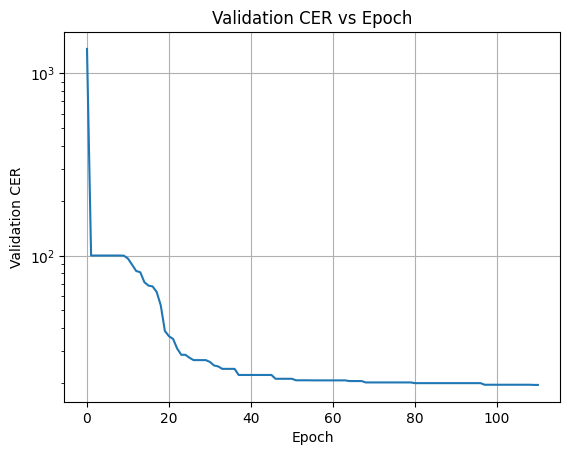

In [16]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load the training log
with open("output.txt", "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()


print("lines:", len(lines))
print("max epoch seen (any line):", max(int(m.group(1)) for l in lines if (m:=re.search(r"Epoch\s+(\d+)", l))))
print("max epoch in train_loss df:", df_loss["epoch"].max())
print("max epoch in val_CER df:", df_cer["epoch"].max())
epoch_loss = []
val_cer = []

current_epoch = None

for line in lines:

    # Detect epoch number
    epoch_match = re.search(r"Epoch\s+(\d+)", line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    # Detect training loss
    loss_match = re.search(r"loss[=:]\s*([0-9]+(?:\.[0-9]+)?)", line)
    if loss_match and current_epoch is not None:
        epoch_loss.append((current_epoch, float(loss_match.group(1))))

    # Detect validation CER
    cer_match = re.search(r"'val/CER'\s+reached\s+([0-9]+(?:\.[0-9]+)?)", line)
    if cer_match and current_epoch is not None:
      val_cer.append((current_epoch, float(cer_match.group(1))))

# Helper to keep only the last value per epoch
def last_value_per_epoch(pairs):
    d = {}
    for e, v in pairs:
        d[e] = v
    return pd.DataFrame({
        "epoch": sorted(d.keys()),
        "value": [d[e] for e in sorted(d.keys())]
    })

df_loss = last_value_per_epoch(epoch_loss)
df_loss.columns = ["epoch", "train_loss"]

df_cer = last_value_per_epoch(val_cer)
df_cer.columns = ["epoch", "val_CER"]

# Merge the tables
df = pd.merge(df_loss, df_cer, on="epoch", how="outer").sort_values("epoch")
df["val_CER"] = df["val_CER"].ffill()

print(df.head())

# Plot training loss
plt.figure()
plt.plot(df["epoch"], df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

# Plot validation CER
plt.figure()
plt.plot(df["epoch"], df["val_CER"])
plt.xlabel("Epoch")
plt.ylabel("Validation CER")
plt.title("Validation CER vs Epoch")
plt.yscale("log")  # helps visualize early huge CER values
plt.grid(True)
plt.show()